# Data Loading

### Importazione Librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests

### Caricamento Dati

In [2]:
CSV_files = {
    "customers":           r"output/customers.csv",
    "geolocation_dataset": r"output/geolocation_dataset.csv",
    "order_items":         r"output/orders_items.csv",
    "order_payments":      r"output/order_payments.csv",
    "order_review":        r"output/order_review.csv",
    "order_dataset":       r"output/order_dataset.csv",
    "list_product":        r"output/list_product.csv",
    "list_seller":         r"output/list_seller.csv"
}
dataframes = {name: pd.read_csv(path) for name, path in CSV_files.items()}

df_customers           = dataframes["customers"]
df_orders_items        = dataframes["order_items"]
df_order_payments      = dataframes["order_payments"]
df_order_review        = dataframes["order_review"]
df_order_dataset       = dataframes["order_dataset"]
df_list_product        = dataframes["list_product"]
df_list_seller         = dataframes["list_seller"]
df_geolocation_dataset = dataframes["geolocation_dataset"]

# TEST D' IPOTESI: verificare se un prodotto con una certa descrizione ha vendite più alte

Ipotesi nulla H0: la lunghezza della descrizione non influenza il numero di vendite.

Ipotesi alternativa H1: la lunghezza della descrizione influenza il numero di vendite

Effettuo un permutation test assegnado alfa del 5% 

In [3]:
product_counts = df_orders_items.groupby("product_id").size().reset_index(name="sales_count")
product_counts['sales_count'].describe()
#conteggio delle vendite per ogni prodotto

count    32951.000000
mean         3.418713
std         10.619709
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        527.000000
Name: sales_count, dtype: float64

In [4]:
df_list_product=df_list_product[['product_id','product_description_lenght','product_category_name_english']]

In [5]:
product_counts

,product_id,sales_count
0,00066f42aeeb9f3007548bb9d3f33c38,1
1,00088930e925c41fd95ebfe695fd2655,1
2,0009406fd7479715e4bef61dd91f2462,1
3,000b8f95fcb9e0096488278317764d19,2
4,000d9be29b5207b54e86aa1b1ac54872,1
...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,2
32947,fff81cc3158d2725c0655ab9ba0f712c,1
32948,fff9553ac224cec9d15d49f5a263411f,1
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,5


In [6]:
df_list_product.sample(2)

,product_id,product_description_lenght,product_category_name_english
21005,7822d1f226e657d5c98ce5a18bd0ad94,433.0,electronics
6132,f4116e296faeae4edac03ac7a501da81,574.0,perfumery


In [7]:
df_test = product_counts.merge(df_list_product, on="product_id", how="left")
df_test=df_test.drop(['product_category_name_english'],axis=1)
df_test['product_description_lenght'].describe()#visualizzo la mediana da usare per dividerla nei due gruppi

count    32341.000000
mean       771.495285
std        635.115225
min          4.000000
25%        339.000000
50%        595.000000
75%        972.000000
max       3992.000000
Name: product_description_lenght, dtype: float64

In [8]:
median_length=595.000000

In [9]:
short = df_test[df_test["product_description_lenght"] <= median_length]["sales_count"].values
long  = df_test[df_test["product_description_lenght"] > median_length]["sales_count"].values
#creazione ei due gruppi

In [10]:
mu_long = np.mean(long)
mu_short = np.mean(short)

obs_diff = mu_long - mu_short   
print(obs_diff)#la differenza fra le medie è di 0.1097

0.10972710690520548


In [11]:
all_sales = np.concatenate([short, long])
n_short = len(short)
# dimensioen del gruppo

In [12]:
n_permutations = 10000
perm_diffs = []

for i in range(n_permutations):
    
    shuffled_sales = np.random.permutation(all_sales)
    
    perm_short = shuffled_sales[:n_short]
    perm_long  = shuffled_sales[n_short:]
    
    mu_diff_temp = perm_long.mean() - perm_short.mean()
    
    perm_diffs.append(mu_diff_temp)

In [13]:
perm_diffs = np.array(perm_diffs)

p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_permutations + 1)

print("p-value:", p_value)


p-value: 0.3588641135886411


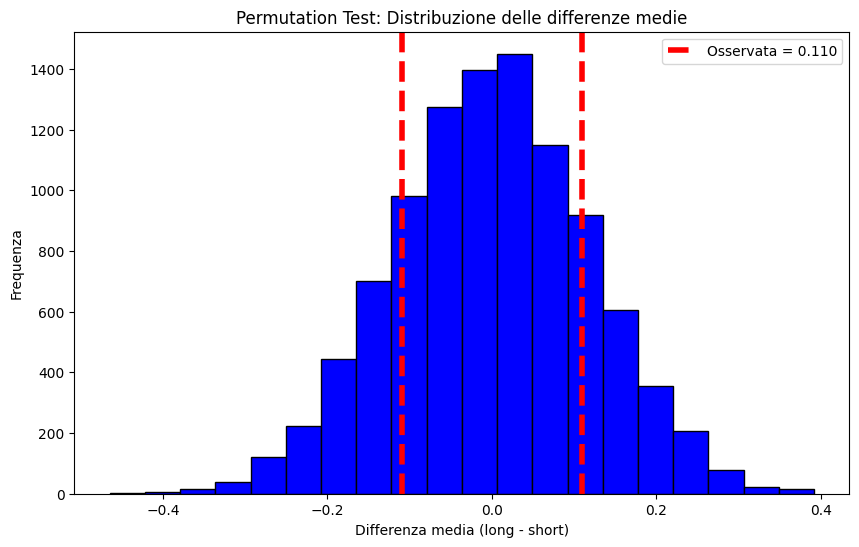

In [14]:
perm_diffs = np.array(perm_diffs)

plt.figure(figsize=(10,6))

# Istogramma delle differenze permutate
plt.hist(perm_diffs, bins=20, color='blue', edgecolor='black')
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=4, label=f'Osservata = {obs_diff:.3f}')
plt.axvline(-obs_diff, color='red', linestyle='dashed', linewidth=4)  # per test a due code

plt.title("Permutation Test: Distribuzione delle differenze medie")
plt.xlabel("Differenza media (long - short)")
plt.ylabel("Frequenza")
plt.legend()
plt.show()

ACCETTIAMO L'IPOTESI NULLA-la lunghezza della descrizione non ha effetto sulle vendite.